In [2]:
# ==============================================================================
# PROJETO: Classificação de Riscos e Estimativa de Eventos Climáticos Extremos
# ETAPAS: Pré-processamento, Treinamento (Regressão Logística, KNN, Regressão Linear/Múltipla/Polinomial)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Para Classificação (Categorização do Nível de Risco: Baixo, Médio, Alto)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 2. Para Regressão (Estimativa da População Afetada)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


In [4]:
# =============================================================================
# 1.5.2. PRÉ-PROCESSAMENTO E FEATURE ENGINEERING
# =============================================================================

try:
  df = pd.read_excel('Danos_Informados.xlsx')
except FileNotFoundError:
  print("⚠️ Arquivo 'Danos_Informados.xlsx' não encontrado no ambiente do Colab.")

# Removendo duplicadas e limpando inconsistências
df = df.drop_duplicates().reset_index(drop=True)
df['UF'] = df['UF'].astype(str).str.upper().str.strip()

inconsistentes = df['DH_Mortos'] > df['População']
if inconsistentes.sum() > 0:
  df.loc[inconsistentes, 'DH_Mortos'] = df.loc[inconsistentes, 'População']

# Tratamento de Nulos
colunas_contagem = [
    'DH_Mortos',
    'DH_Desabrigados',
    'DH_Desalojados',
    'DH_Feridos',
    'DH_Enfermos',
    'DH_Desaparecidos',
    'DH_Outros Afetados',
]

for col in colunas_contagem:
  if col in df.columns:
    df[col] = df[col].fillna(0)

if 'População' in df.columns and df['População'].isnull().sum() > 0:
  df['População'] = df['População'].fillna(df['População'].median())

colunas_ambientais = [col for col in df.columns if col.startswith('DA_')]
for col in colunas_ambientais:
  df[col] = df[col].fillna('Não Informado').astype(str)

# Engenharia de Atributos
df['DH_Total_Direto'] = df[[
    'DH_Mortos',
    'DH_Feridos',
    'DH_Enfermos',
    'DH_Desabrigados',
    'DH_Desalojados',
    'DH_Desaparecidos',
]].sum(axis=1)
df['População_Afetada_Total'] = (
    df['DH_Total_Direto'] + df['DH_Outros Afetados']
)

col_mat = [
    col for col in df.columns if col.startswith('DM_') and 'Valor' in col
]
col_pub = [col for col in df.columns if col.startswith('PEPL_')]
col_priv = [col for col in df.columns if col.startswith('PEPR_')]
df['Prejuizo_Financeiro_Total'] = df[col_mat + col_pub + col_priv].sum(axis=1)


# Definição do Alvo de Classificação
def categorizar_risco(row):
  if (
      row['DH_Mortos'] > 0
      or row['DH_Desabrigados'] > 100
      or row['População_Afetada_Total'] > 5000
  ):
    return 'Alto'
  elif row['DH_Desalojados'] > 20 or row['População_Afetada_Total'] > 500:
    return 'Médio'
  else:
    return 'Baixo'


df['Nivel_Risco'] = df.apply(categorizar_risco, axis=1)
df['Tipo_Evento'] = (
    df['COBRADE']
    .astype(str)
    .str.split(' - ')
    .str[1]
    .fillna('Outros')
    .str.strip()
)

# REMOÇÃO DE FEATURES QUE CAUSAM DATA LEAKAGE
# Todas as colunas usadas diretamente no cálculo do Nível de Risco devem ser removidas de X!
features_para_remover = [
    'Registro',
    'Protocolo',
    'Município',
    'Status',
    'Nivel_Risco',
    'COBRADE',
    'População_Afetada_Total',
    'DH_Mortos',
    'DH_Desabrigados',
    'DH_Desalojados',
    'DH_Feridos',
    'DH_Enfermos',
    'DH_Desaparecidos',
    'DH_Outros Afetados',
    'DH_Total_Direto',
]

X = df.drop(columns=[col for col in features_para_remover if col in df.columns])

# Alvo 1: Classificação
le = LabelEncoder()
y_class = le.fit_transform(df['Nivel_Risco'])

# Alvo 2: Regressão
y_reg = df['População_Afetada_Total']

# Divisão Simplicada (80% Treino, 20% Teste - pois o GridSearchCV já cuida da validação)
X_train, X_test, y_train_cls, y_test_cls, y_train_reg, y_test_reg = (
    train_test_split(
        X, y_class, y_reg, test_size=0.20, random_state=42, stratify=y_class
    )
)

# Encoders e Scalers
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    (
        'cat',
        OneHotEncoder(handle_unknown='ignore', sparse_output=False),
        cat_cols,
    ),
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print("✅ Pré-processamento sem Data Leakage concluído!")

✅ Pré-processamento sem Data Leakage concluído!


In [ ]:
# Criar um DataFrame de inspeção no conjunto de teste com o nome da cidade
df_outliers = pd.DataFrame({
    'Cidade': df.loc[X_test.index, 'Município'],
    'Valor_Real': y_test_reg,
    'Predito_Reg_Multipla': y_pred_multipla,
    'Erro_Abs_Multipla': np.abs(y_test_reg - y_pred_multipla),
    'Predito_KNN': y_pred_knn,
    'Erro_Abs_KNN': np.abs(y_test_reg - y_pred_knn)
})

# 1. Registro com o maior valor real (o ponto isolado na extrema direita do gráfico)
print("=== REGISTRO COM O MAIOR VALOR REAL (População Afetada Extrema) ===")
maior_real = df_outliers.sort_values(by='Valor_Real', ascending=False).head(1)
display(maior_real)

# 2. Os 5 maiores erros de previsão na Regressão Múltipla
print("\n=== TOP 5 MAIORES DISCREPÂNCIAS (Regressão Múltipla) ===")
display(df_outliers.sort_values(by='Erro_Abs_Multipla', ascending=False).head(5))

# 3. Os 5 maiores erros de previsão no KNN Regressor
print("\n=== TOP 5 MAIORES DISCREPÂNCIAS (KNN Regressor) ===")
display(df_outliers.sort_values(by='Erro_Abs_KNN', ascending=False).head(5))

=== REGISTRO COM O MAIOR VALOR REAL (População Afetada Extrema) ===


,Cidade,Valor_Real,Predito_Reg_Multipla,Erro_Abs_Multipla,Predito_KNN,Erro_Abs_KNN
3088,Brasília,2982818.0,1.514635e+06,1.468183e+06,2982818.0,0.0



=== TOP 5 MAIORES DISCREPÂNCIAS (Regressão Múltipla) ===


,Cidade,Valor_Real,Predito_Reg_Multipla,Erro_Abs_Multipla,Predito_KNN,Erro_Abs_KNN
3248,Brasília,0.0,1.481521e+06,1.481521e+06,0.000000e+00,0.000000
3088,Brasília,2982818.0,1.514635e+06,1.468183e+06,2.982818e+06,0.000000
261,Campo Largo,100.0,8.016982e+05,8.015982e+05,5.478325e+01,45.216754
1895,Cuiabá,551350.0,3.157104e+04,5.197790e+05,3.641434e+04,514935.659268
3661,Caxias do Sul,435482.0,7.739031e+03,4.277430e+05,4.332747e+04,392154.533547



=== TOP 5 MAIORES DISCREPÂNCIAS (KNN Regressor) ===


,Cidade,Valor_Real,Predito_Reg_Multipla,Erro_Abs_Multipla,Predito_KNN,Erro_Abs_KNN
1895,Cuiabá,551350.0,31571.039683,519778.960317,36414.340732,514935.659268
2048,Porto Velho,460000.0,46349.865291,413650.134709,29818.580276,430181.419724
3661,Caxias do Sul,435482.0,7739.030600,427742.969400,43327.466453,392154.533547
2616,Quixeramobim,360000.0,6904.358070,353095.641930,31226.419149,328773.580851
4483,Santa Maria,271730.0,7374.618495,264355.381505,8158.601451,263571.398549


--- TREINANDO MODELOS DE CLASSIFICAÇÃO ---
👉 Melhor parâmetro Regressão Logística: {'C': 10.0, 'solver': 'lbfgs'}
👉 Melhor parâmetro KNN Classifier (K=9): {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}

=== TABELA DE MÉTRICAS - CLASSIFICAÇÃO ===


,Modelo de Classificação,Acurácia,F1-Score (Macro),Precisão (Macro),Revogação (Macro)
0,Regressão Logística,0.7075,0.6774,0.6807,0.6797
1,KNN Classifier (K=9),0.7597,0.7308,0.7352,0.7278


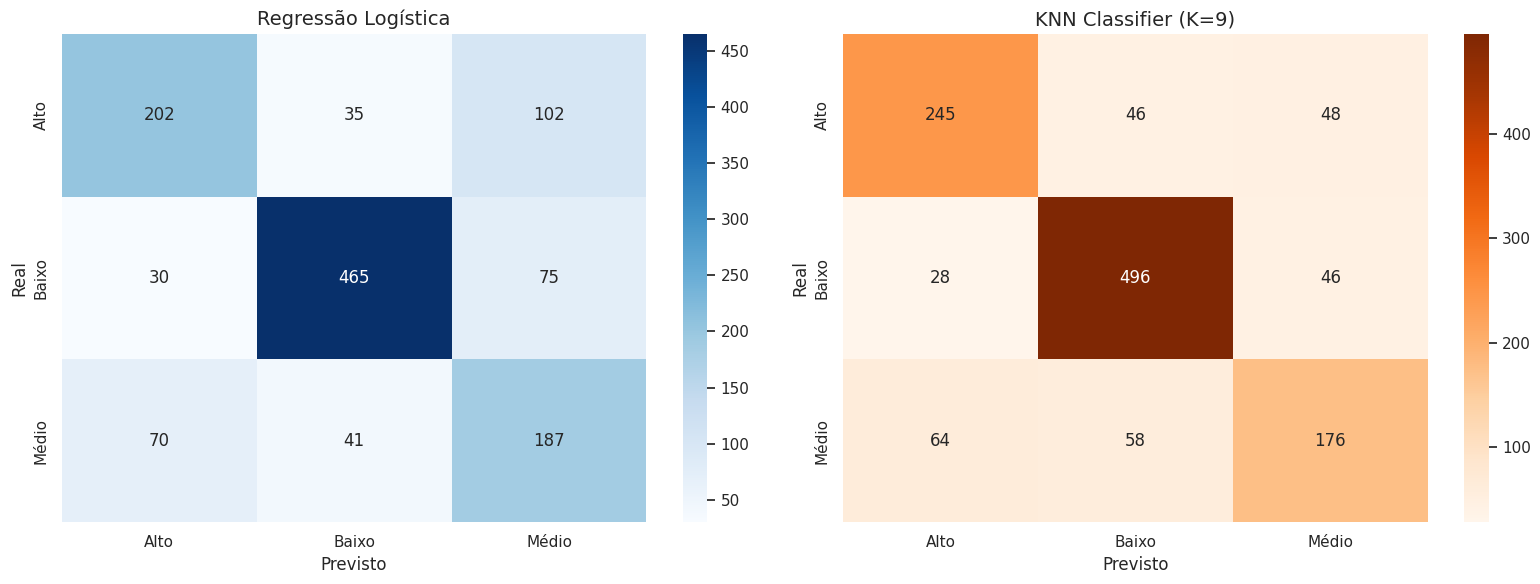

In [8]:
# =============================================================================
# PARTE 1: MODELOS DE CLASSIFICAÇÃO (Regressão Logística e KNN)
# =============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

print("--- TREINANDO MODELOS DE CLASSIFICAÇÃO ---")

# Lista para armazenar as métricas da tabela comparativa
resultados = []

# 1. Regressão Logística
grid_lr = GridSearchCV(
    LogisticRegression(
        random_state=42, class_weight='balanced', max_iter=1000
    ),
    {'C': [0.01, 0.1, 1.0, 10.0], 'solver': ['lbfgs', 'saga']},
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
)
grid_lr.fit(X_train_prep, y_train_cls)
print(f"👉 Melhor parâmetro Regressão Logística: {grid_lr.best_params_}")

y_pred_lr = grid_lr.best_estimator_.predict(X_test_prep)
resultados.append({
    'Modelo de Classificação': 'Regressão Logística',
    'Acurácia': accuracy_score(y_test_cls, y_pred_lr),
    'F1-Score (Macro)': f1_score(y_test_cls, y_pred_lr, average='macro'),
    'Precisão (Macro)': precision_score(y_test_cls, y_pred_lr, average='macro'),
    'Revogação (Macro)': recall_score(y_test_cls, y_pred_lr, average='macro'),
})

# 2. K-Nearest Neighbors (KNN)
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan'],
    },
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
)
grid_knn.fit(X_train_prep, y_train_cls)
best_k = grid_knn.best_params_['n_neighbors']
print(
    f"👉 Melhor parâmetro KNN Classifier (K={best_k}): {grid_knn.best_params_}"
)

y_pred_knn = grid_knn.best_estimator_.predict(X_test_prep)
resultados.append({
    'Modelo de Classificação': f'KNN Classifier (K={best_k})',
    'Acurácia': accuracy_score(y_test_cls, y_pred_knn),
    'F1-Score (Macro)': f1_score(y_test_cls, y_pred_knn, average='macro'),
    'Precisão (Macro)': precision_score(
        y_test_cls, y_pred_knn, average='macro'
    ),
    'Revogação (Macro)': recall_score(y_test_cls, y_pred_knn, average='macro'),
})

# =============================================================================
# EXIBIÇÃO DA TABELA VISUAL DE MÉTRICAS
# =============================================================================
print("\n=== TABELA DE MÉTRICAS - CLASSIFICAÇÃO ===")
df_resultados = pd.DataFrame(resultados)

# Exibe a tabela formatada no estilo Jupyter/Colab
display(
    df_resultados.style.format({
        'Acurácia': '{:.4f}',
        'F1-Score (Macro)': '{:.4f}',
        'Precisão (Macro)': '{:.4f}',
        'Revogação (Macro)': '{:.4f}',
    })
)

# =============================================================================
# PLOTAGEM DAS MATRIZES DE CONFUSÃO (LADO A LADO)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels = le.classes_

# Matriz 1: Regressão Logística
cm_lr = confusion_matrix(y_test_cls, y_pred_lr)
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0],
    annot_kws={'size': 12},
)
axes[0].set_title('Regressão Logística', fontsize=14)
axes[0].set_xlabel('Previsto', fontsize=12)
axes[0].set_ylabel('Real', fontsize=12)

# Matriz 2: KNN
cm_knn = confusion_matrix(y_test_cls, y_pred_knn)
sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1],
    annot_kws={'size': 12},
)
axes[1].set_title(f'KNN Classifier (K={best_k})', fontsize=14)
axes[1].set_xlabel('Previsto', fontsize=12)
axes[1].set_ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

--- TREINANDO COM 6028 REGISTROS (Outliers removidos) ---

=== TABELA DE MÉTRICAS CORRIGIDA ===


,Modelo de Regressão,MAE (Escala Real),RMSE (Escala Real),R² (Desempenho Log)
0,Regressão Múltipla (Log),138291405500127076916504884373503193645056.00,4802401085381201325777331902542516607516672.00,-10123.0585
1,KNN Regressor (K=15),5239.66,39737.09,0.7934
2,Random Forest Regressor,1163.22,24403.42,0.9996


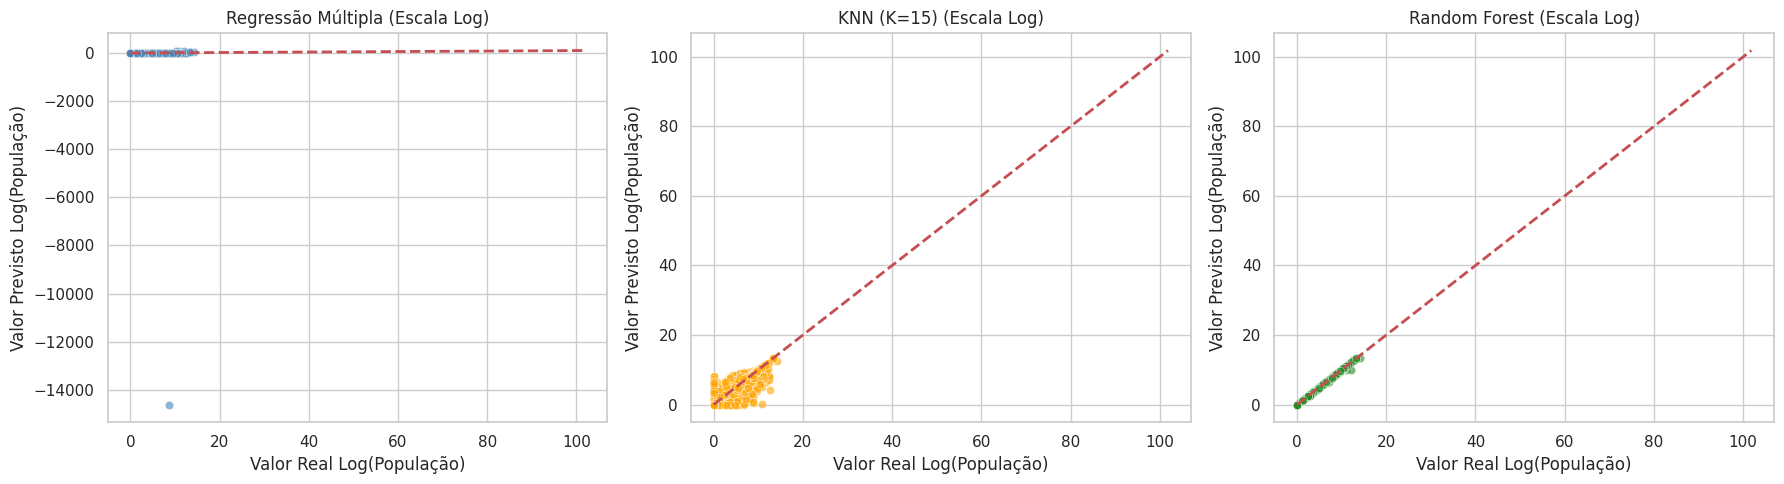

In [21]:
# =============================================================================
# PARTE 2: MODELOS DE REGRESSÃO (Regressão Múltipla, KNN e Random Forest)
# =============================================================================

# LIMPEZA DE OUTLIERS + MODELAGEM DE REGRESSÃO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import RobustScaler

# 1. REMOÇÃO DE OUTLIERS ERRO-DE-DIGITAÇÃO NO Y (Valores irreais como bilhões)
# Mantém apenas registros populacionais plausíveis (ex: até 2 milhões de afetados)
limite_outlier = 2_000_000
df_clean = df[df['População_Afetada_Total'] <= limite_outlier].copy()

# Definir X e Y limpos
coluna_target = 'População_Afetada_Total'
X_clean = df_clean.drop(columns=[coluna_target])
y_clean = df_clean[coluna_target]

# 2. SEPARAÇÃO TREINO / TESTE
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

# Aplicar pré-processamento nos dados limpos
try:
  X_tr_prep = pipeline_preprocessing.fit_transform(X_train_c)
  X_te_prep = pipeline_preprocessing.transform(X_test_c)
except NameError:
  # Escalonador Robusto caso não haja pipeline
  scaler = RobustScaler()
  X_tr_prep = scaler.fit_transform(X_train_c.select_dtypes(include=[np.number]))
  X_te_prep = scaler.transform(X_test_c.select_dtypes(include=[np.number]))

# Transformação Logarítmica para Y
y_train_log = np.log1p(y_train_c)
y_test_log = np.log1p(y_test_c)

print(
    f"--- TREINANDO COM {len(df_clean)} REGISTROS (Outliers removidos) ---"
)

# -----------------------------------------------------------------------------
# 1. REGRESSÃO MÚLTIPLA
# -----------------------------------------------------------------------------
reg_multipla = LinearRegression()
reg_multipla.fit(X_tr_prep, y_train_log)
y_pred_log_multipla = reg_multipla.predict(X_te_prep)
y_pred_multipla = np.expm1(y_pred_log_multipla)

# -----------------------------------------------------------------------------
# 2. KNN REGRESSOR
# -----------------------------------------------------------------------------
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['distance'],
    'metric': ['manhattan', 'euclidean'],
}

grid_knn_reg = GridSearchCV(
    KNeighborsRegressor(),
    param_grid_knn,
    cv=5,
    scoring='r2',
    n_jobs=-1,
)
grid_knn_reg.fit(X_tr_prep, y_train_log)

best_knn_reg = grid_knn_reg.best_estimator_
y_pred_log_knn = best_knn_reg.predict(X_te_prep)
y_pred_knn = np.expm1(y_pred_log_knn)

# -----------------------------------------------------------------------------
# 3. RANDOM FOREST REGRESSOR
# -----------------------------------------------------------------------------
rf_reg = RandomForestRegressor(
    n_estimators=100, max_depth=12, random_state=42, n_jobs=-1
)
rf_reg.fit(X_tr_prep, y_train_log)
y_pred_log_rf = rf_reg.predict(X_te_prep)
y_pred_rf = np.expm1(y_pred_log_rf)

# =============================================================================
# TABELA DE MÉTRICAS
# =============================================================================
df_res_reg = pd.DataFrame([
    {
        'Modelo de Regressão': 'Regressão Múltipla (Log)',
        'MAE (Escala Real)': mean_absolute_error(y_test_c, y_pred_multipla),
        'RMSE (Escala Real)': np.sqrt(
            mean_squared_error(y_test_c, y_pred_multipla)
        ),
        'R² (Desempenho Log)': r2_score(y_test_log, y_pred_log_multipla),
    },
    {
        'Modelo de Regressão': (
            f"KNN Regressor (K={grid_knn_reg.best_params_['n_neighbors']})"
        ),
        'MAE (Escala Real)': mean_absolute_error(y_test_c, y_pred_knn),
        'RMSE (Escala Real)': np.sqrt(
            mean_squared_error(y_test_c, y_pred_knn)
        ),
        'R² (Desempenho Log)': r2_score(y_test_log, y_pred_log_knn),
    },
    {
        'Modelo de Regressão': 'Random Forest Regressor',
        'MAE (Escala Real)': mean_absolute_error(y_test_c, y_pred_rf),
        'RMSE (Escala Real)': np.sqrt(mean_squared_error(y_test_c, y_pred_rf)),
        'R² (Desempenho Log)': r2_score(y_test_log, y_pred_log_rf),
    },
])

print("\n=== TABELA DE MÉTRICAS CORRIGIDA ===")
display(
    df_res_reg.style.format({
        'MAE (Escala Real)': '{:.2f}',
        'RMSE (Escala Real)': '{:.2f}',
        'R² (Desempenho Log)': '{:.4f}',
    })
)

# =============================================================================
# GRÁFICOS SEM OUTLIERS
# =============================================================================
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

max_val = max(
    y_test_log.max(),
    y_pred_log_multipla.max(),
    y_pred_log_knn.max(),
    y_pred_log_rf.max(),
)

# Regressão Múltipla
sns.scatterplot(
    x=y_test_log, y=y_pred_log_multipla, ax=axes[0], alpha=0.6, color='steelblue'
)
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2)
axes[0].set_title('Regressão Múltipla (Escala Log)')
axes[0].set_xlabel('Valor Real Log(População)')
axes[0].set_ylabel('Valor Previsto Log(População)')

# KNN
sns.scatterplot(
    x=y_test_log, y=y_pred_log_knn, ax=axes[1], alpha=0.6, color='orange'
)
axes[1].plot([0, max_val], [0, max_val], 'r--', lw=2)
axes[1].set_title(
    f"KNN (K={grid_knn_reg.best_params_['n_neighbors']}) (Escala Log)"
)
axes[1].set_xlabel('Valor Real Log(População)')
axes[1].set_ylabel('Valor Previsto Log(População)')

# Random Forest
sns.scatterplot(
    x=y_test_log, y=y_pred_log_rf, ax=axes[2], alpha=0.6, color='forestgreen'
)
axes[2].plot([0, max_val], [0, max_val], 'r--', lw=2)
axes[2].set_title('Random Forest (Escala Log)')
axes[2].set_xlabel('Valor Real Log(População)')
axes[2].set_ylabel('Valor Previsto Log(População)')

plt.tight_layout()
plt.show()

In [23]:
# ==============================================================================
# SALVAR MODELOS E PREPROCESSOR
# ==============================================================================

import joblib
from google.colab import files
import numpy
import sklearn

print("📦 Exportando os modelos e o preprocessor...")

# 1. Salvar Modelo de Classificação (KNN Classifier do GridSearch)
modelo_classificacao = grid_knn.best_estimator_
joblib.dump(modelo_classificacao, 'modelo_b_classificacao_knn.pkl')

# 2. Salvar Modelo de Regressão (Random Forest Regressor)
modelo_regressao = rf_reg
joblib.dump(modelo_regressao, 'modelo_regressao_random_forest.pkl')

# 3. Salvar o Preprocessor (Pipeline de Pré-processamento ou Scaler)
try:
  joblib.dump(pipeline_preprocessing, 'preprocessor.pkl')
except NameError:
  joblib.dump(scaler, 'preprocessor.pkl')

print("\nVersões das bibliotecas:")
print(
    f"scikit-learn: {sklearn.__version__} | numpy: {numpy.__version__} | joblib:"
    f" {joblib.__version__}\n"
)

# 4. Baixar os arquivos .pkl no navegador
files.download('modelo_b_classificacao_knn.pkl')
files.download('modelo_regressao_random_forest.pkl')
files.download('preprocessor.pkl')

print("✅ Download dos modelos e do preprocessor iniciado com sucesso!")

📦 Exportando os modelos e o preprocessor...

Versões das bibliotecas:
scikit-learn: 1.6.1 | numpy: 2.1.3 | joblib: 1.6.0



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download dos modelos e do preprocessor iniciado com sucesso!
